In [ ]:
import pandas as pd
import numpy as np
import re
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import resample
from collections import Counter
import tensorflow as tf

In [ ]:
# =========================
# Load Dataset
# =========================
data_path = "/content/different_types_of_disaster_processed.xlsx"  # update if needed
data = pd.read_excel(data_path)


In [ ]:
# =========================
# Text Cleaning Function
# =========================
def clean_text(text):
    text = re.sub(r"http\S+|www\S+", "", str(text))   # remove URLs
    text = re.sub(r"@\w+|#", "", text)                # remove mentions/hashtags
    text = re.sub(r"[^A-Za-z\s]", "", text)           # keep only letters
    return text.lower().strip()


In [ ]:
# Apply cleaning
data['clean_tweet'] = data['tweet_text'].apply(clean_text)
data = data.dropna(subset=['disaster_type'])

In [ ]:
# =========================
# Encode Labels
# =========================
label_enc = LabelEncoder()
data['label'] = label_enc.fit_transform(data['disaster_type'])

In [ ]:
# =========================
# Train-Test Split
# =========================
X = data['clean_tweet']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Before balancing (train set):", Counter(y_train))

Before balancing (train set): Counter({5: 12685, 2: 5026, 7: 4923, 3: 3895, 9: 2146, 11: 1507, 4: 1074, 1: 1017, 6: 569, 0: 528, 8: 407, 10: 315, 12: 270})


In [ ]:
# =========================
# Balancing Training Data (Oversample minority + Undersample majority)
# =========================
train_df = pd.DataFrame({'clean_tweet': X_train, 'label': y_train})

counts = Counter(train_df['label'])
max_count = max(counts.values())
min_count = min(counts.values())

In [ ]:
# Step 1: Oversample minority classes to match max_count
oversampled_list = []
for label in counts:
    df_label = train_df[train_df['label'] == label]
    if len(df_label) < max_count:
        df_label = resample(
            df_label,
            replace=True,
            n_samples=max_count,
            random_state=42
        )
    oversampled_list.append(df_label)
train_df_over = pd.concat(oversampled_list)

In [ ]:
# Step 2: Undersample all classes to midpoint between max_count and min_count
target_count = int((max_count + min_count) / 2)
final_balanced_list = []
for label in Counter(train_df_over['label']):
    df_label = train_df_over[train_df_over['label'] == label]
    if len(df_label) > target_count:
        df_label = resample(
            df_label,
            replace=False,
            n_samples=target_count,
            random_state=42
        )
    final_balanced_list.append(df_label)
train_df_balanced = pd.concat(final_balanced_list)


In [ ]:
# Updated X_train, y_train
X_train = train_df_balanced['clean_tweet']
y_train = train_df_balanced['label']

print("After balancing (train set):", Counter(y_train))

After balancing (train set): Counter({5: 6477, 3: 6477, 2: 6477, 7: 6477, 1: 6477, 11: 6477, 4: 6477, 8: 6477, 9: 6477, 10: 6477, 12: 6477, 6: 6477, 0: 6477})


In [ ]:
# =========================
# Tokenization & Padding
# =========================
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [ ]:
# =========================
# Model Architecture
# =========================
model = Sequential()
model.add(Embedding(max_words, 128, input_length=max_len))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(32)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(label_enc.classes_), activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# =========================
# Training
# =========================
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.2, verbose=1)

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
1316/1316 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.6871 - loss: 0.8984 - val_accuracy: 0.9845 - val_loss: 0.0631 - learning_rate: 0.0010
Epoch 2/10
1316/1316 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.9946 - loss: 0.0283 - val_accuracy: 0.9875 - val_loss: 0.0629 - learning_rate: 0.0010
Epoch 3/10
1316/1316 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.9970 - loss: 0.0146 - val_accuracy: 0.9858 - val_loss: 0.0793 - learning_rate: 0.0010
Epoch 4/10
1315/1316 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9977 - loss: 0.0122
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
1316/1316 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.9977 - loss: 0.0122 - val_accuracy: 0.9892 - val_loss: 0.0706 - learning_rate: 0.0010
Epoch 5/10
1316/1316 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9992 - loss: 0.0045 - val_accuracy: 0.9891 - val_loss: 0.0851 - learning_rate: 2.0000e-04


In [ ]:
# =========================
# Evaluation
# =========================
y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nClassification Report:\n", classification_report(y_test, y_pred_classes, target_names=label_enc.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_classes))

269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

Classification Report:
                   precision    recall  f1-score   support

         bombing       0.96      0.97      0.96       132
         cyclone       0.98      0.98      0.98       254
      earthquake       1.00      0.99      0.99      1257
       explosion       1.00      0.99      0.99       974
            fire       0.98      0.97      0.98       268
           flood       0.99      0.99      0.99      3171
helicopter crash       1.00      0.99      1.00       142
       hurricane       0.98      0.99      0.99      1231
        shooting       0.99      0.98      0.99       102
         tornado       0.94      0.98      0.96       537
     train crash       0.99      1.00      0.99        79
         typhoon       0.99      0.98      0.98       377
        wildfire       0.97      1.00      0.99        67

        accuracy                           0.99      8591
       macro avg       0.98      0.99      0.98      8591
    

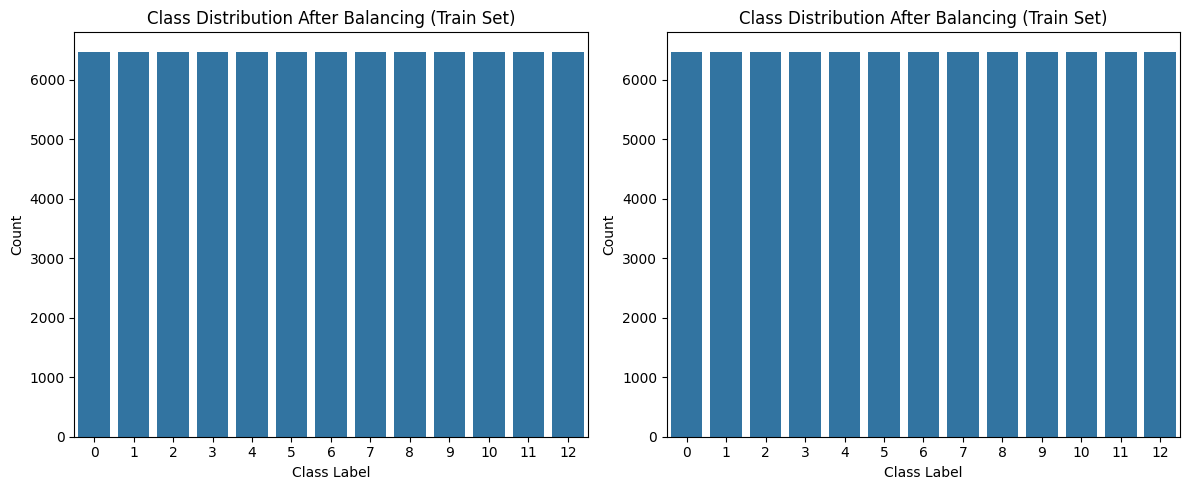

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# =========================
# 1. Class Distribution Before & After Balancing
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before balancing
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Class Distribution After Balancing (Train Set)")
axes[0].set_xlabel("Class Label")
axes[0].set_ylabel("Count")

# After balancing (we saved train_df_balanced)
sns.countplot(x=train_df_balanced['label'], ax=axes[1])
axes[1].set_title("Class Distribution After Balancing (Train Set)")
axes[1].set_xlabel("Class Label")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

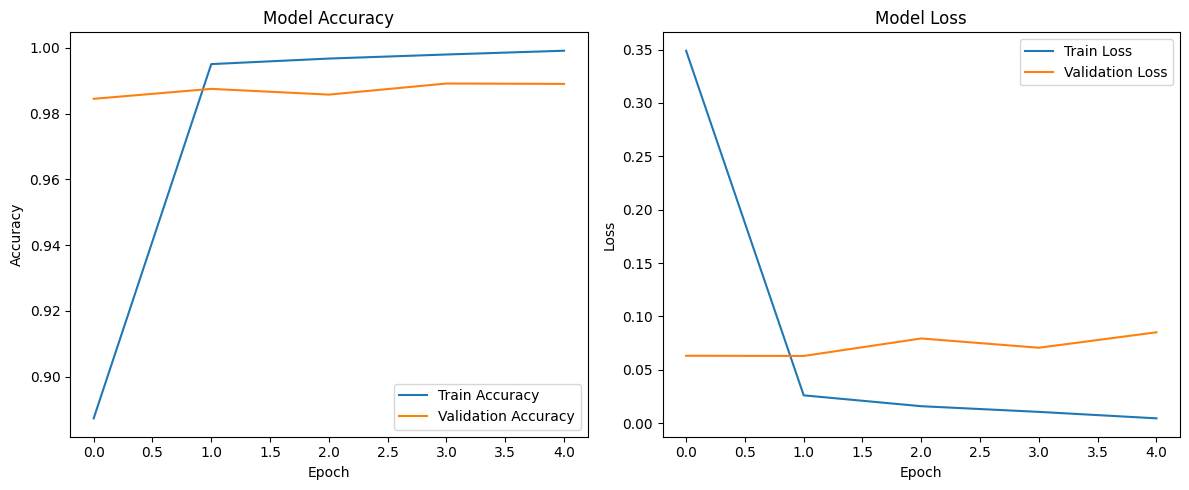

In [ ]:
# =========================
# 2. Training History Curves
# =========================
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

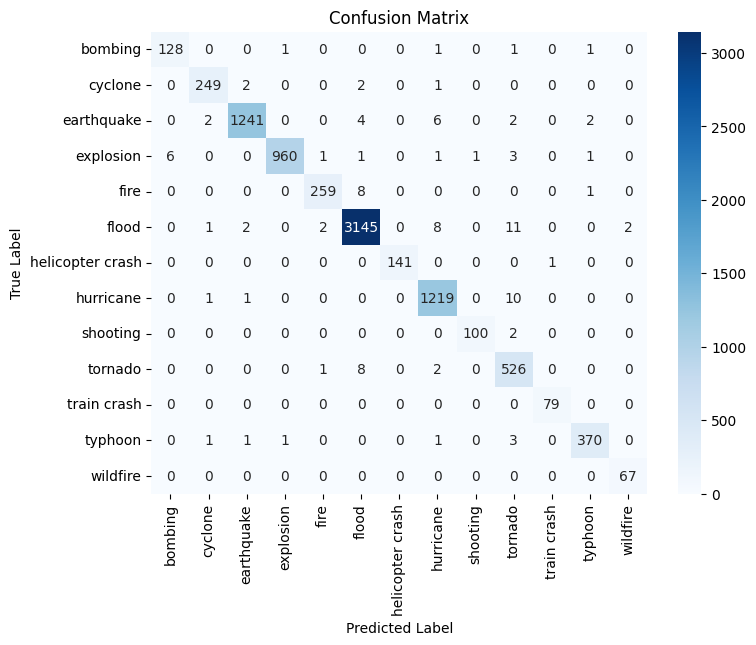

In [ ]:
# =========================
# 3. Confusion Matrix Heatmap
# =========================
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_enc.classes_,
            yticklabels=label_enc.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


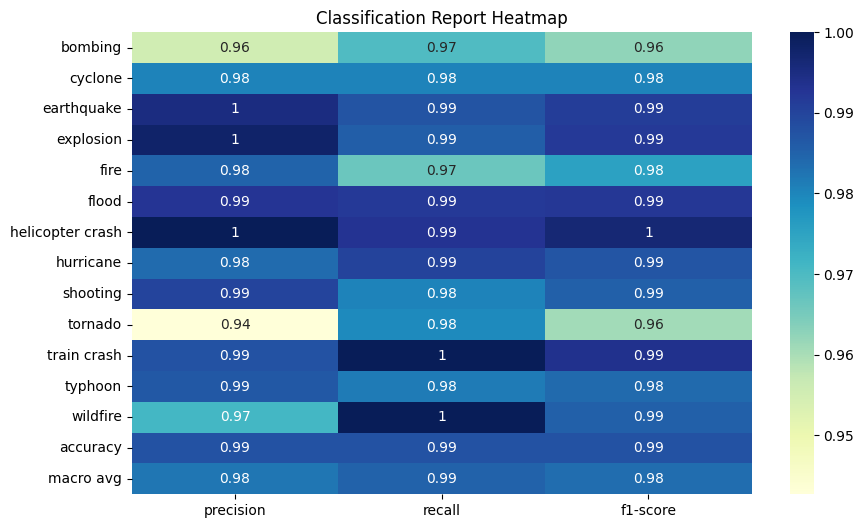

In [ ]:
# =========================
# 4. Classification Report Heatmap
# =========================
report_dict = classification_report(
    y_test, y_pred_classes,
    target_names=label_enc.classes_,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose()

plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='YlGnBu')
plt.title("Classification Report Heatmap")
plt.show()


In [ ]:
# import shap

# # =========================
# # 1. Create Explainer
# # =========================
# # For a neural network (e.g., Keras model)
# # Use the padded training data for the explainer
# explainer = shap.KernelExplainer(model.predict, X_train_pad[:100])  # use a sample for efficiency

# # =========================
# # 2. Explain Predictions
# # =========================
# # Explain first 10 test instances using padded data
# shap_values = explainer.shap_values(X_test_pad[:10])

# # =========================
# # 3. Visualize Explanation
# # =========================
# # Summary plot for feature importance
# # Adjust feature names to reflect tokenized and padded sequences
# feature_names = [f'word_{i}' for i in range(X_test_pad.shape[1])]
# shap.summary_plot(shap_values, X_test_pad[:10], feature_names=feature_names)

# # Force plot for a single instance
# shap.initjs()
# # Use the padded test data for the force plot
# shap.force_plot(explainer.expected_value[0], shap_values[0][0], X_test_pad[0], feature_names=feature_names)

In [ ]:
# =========================
# XAI Implementation
# =========================
import shap
import lime
import lime.lime_text

# Option 1: LIME for text classification
from lime.lime_text import LimeTextExplainer

explainer_lime = LimeTextExplainer(class_names=label_enc.classes_)

# Explain a single prediction
idx = 0  # index of test sample
exp = explainer_lime.explain_instance(
    X_test.iloc[idx],  # raw text
    model.predict,      # prediction function
    num_features=10,
    num_samples=1000
)
exp.show_in_notebook(text=True)

# Option 2: SHAP with KernelExplainer
# Use a sample for efficiency
background = X_train_pad[np.random.choice(X_train_pad.shape[0], 100, replace=False)]
explainer_shap = shap.KernelExplainer(model.predict, background)

# Get SHAP values for test samples
shap_values = explainer_shap.shap_values(X_test_pad[:5], nsamples=100)
shap.summary_plot(shap_values, X_test_pad[:5], feature_names=[f'word_{i}' for i in range(100)])